In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("Credit Card customers export 2026-05-20 11-33-34.csv", engine='python', on_bad_lines='warn')

/tmp/ipykernel_5410/3701791887.py:1: ParserWarning: Skipping line 5721: unexpected end of data

  df = pd.read_csv("Credit Card customers export 2026-05-20 11-33-34.csv", engine='python', on_bad_lines='warn')


In [9]:
df.shape

(5719, 23)

In [10]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [11]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5719 entries, 0 to 5718
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           5719 non-null   int64  
 1   Attrition_Flag                                                                                                                      5719 non-null   object 
 2   Customer_Age                                                                                                                        5719 non-null   int64  
 3   Gender                                                                             

In [14]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [15]:
df = df.drop(columns=[
'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
])

In [17]:
df['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
Existing Customer,4987
Attrited Customer,732


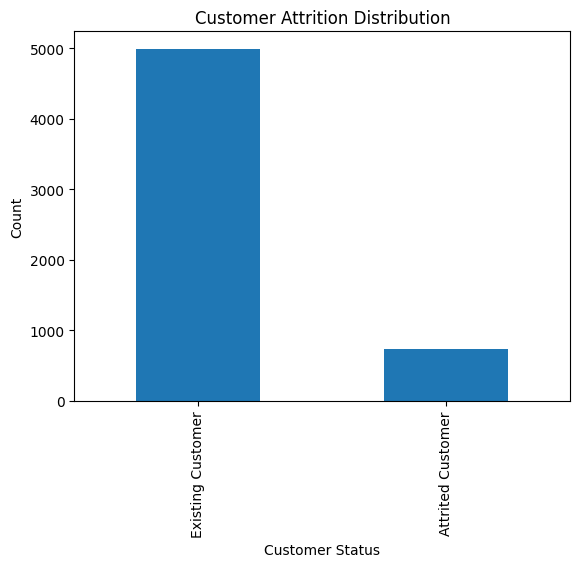

In [18]:
df['Attrition_Flag'].value_counts().plot(kind='bar')

plt.title("Customer Attrition Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Count")

plt.show()

In [19]:
(
df['Attrition_Flag']
.value_counts(normalize=True)*100
).round(2)

,proportion
Attrition_Flag,
Existing Customer,87.2
Attrited Customer,12.8


In [20]:
df['Gender'].value_counts()

,count
Gender,
M,3033
F,2686


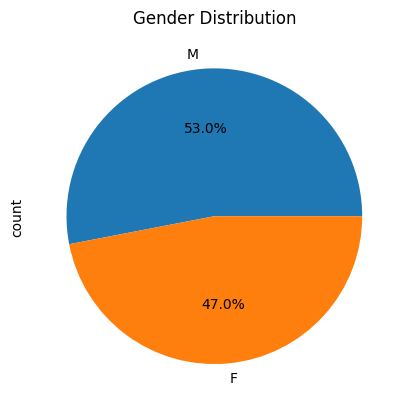

In [21]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Gender Distribution")

plt.show()

In [22]:
df['Income_Category'].value_counts()

,count
Income_Category,
Less than $40K,1834
$40K - $60K,979
$80K - $120K,972
$60K - $80K,895
Unknown,588
$120K +,451


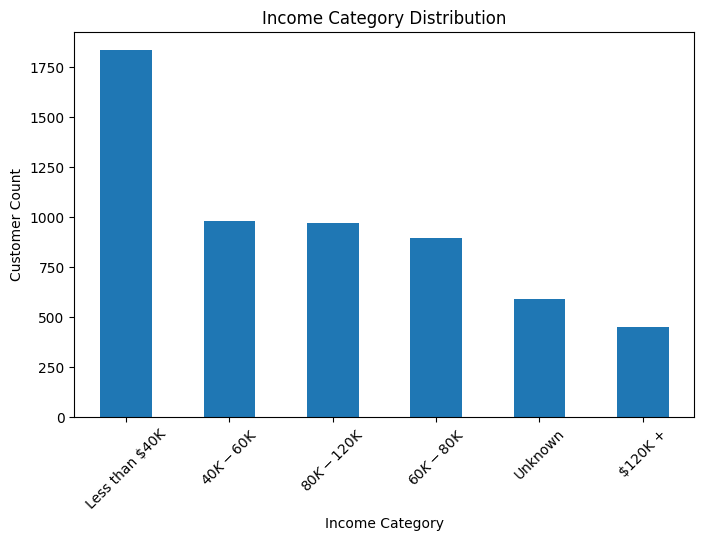

In [23]:
df['Income_Category'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Income Category Distribution")
plt.xlabel("Income Category")
plt.ylabel("Customer Count")

plt.xticks(rotation=45)

plt.show()

In [24]:
pd.crosstab(
    df['Income_Category'],
    df['Attrition_Flag']
)

Attrition_Flag,Attrited Customer,Existing Customer
Income_Category,,
$120K +,60,391
$40K - $60K,123,856
$60K - $80K,98,797
$80K - $120K,108,864
Less than $40K,256,1578
Unknown,87,501


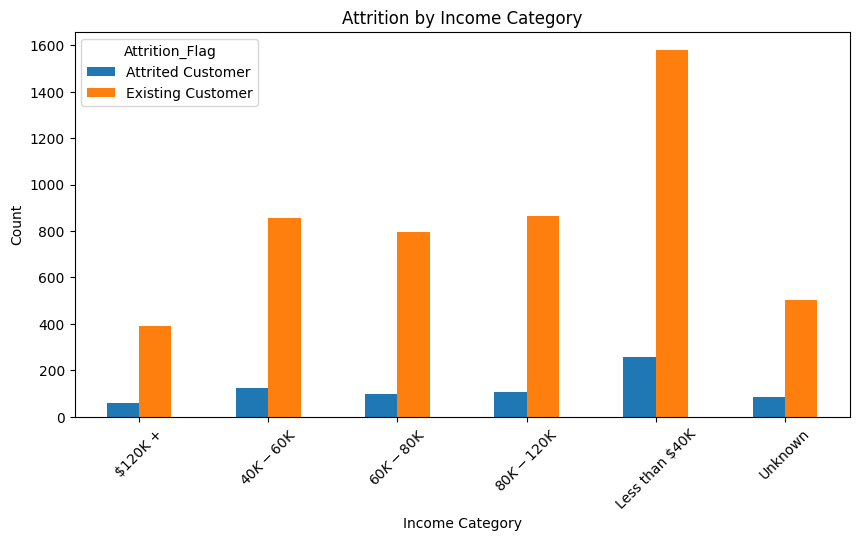

In [25]:
pd.crosstab(
    df['Income_Category'],
    df['Attrition_Flag']
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Attrition by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [26]:
df['Credit_Limit'].describe()

,Credit_Limit
count,5719.000000
mean,8860.718482
std,8880.825101
min,1438.300000
25%,2683.500000
50%,5146.000000
75%,11563.000000
max,34516.000000


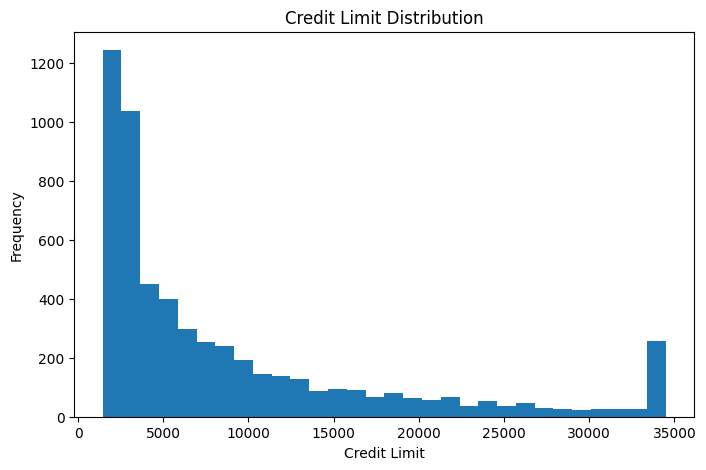

In [27]:
df['Credit_Limit'].plot(
    kind='hist',
    bins=30,
    figsize=(8,5)
)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")

plt.show()

In [28]:
df.groupby('Attrition_Flag')['Credit_Limit'].mean()

,Credit_Limit
Attrition_Flag,
Attrited Customer,8071.437158
Existing Customer,8976.570483


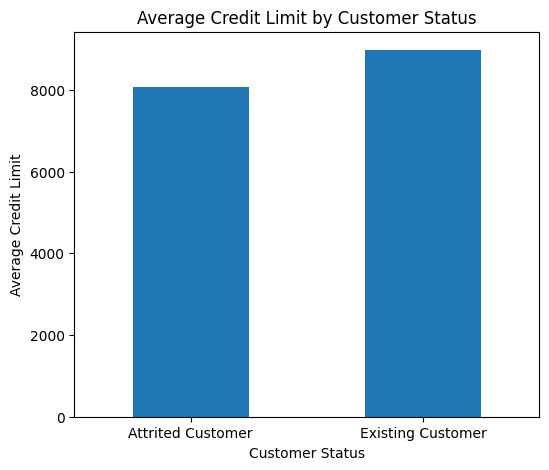

In [29]:
df.groupby('Attrition_Flag')['Credit_Limit'].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Average Credit Limit by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Credit Limit")

plt.xticks(rotation=0)

plt.show()

In [30]:
df.groupby('Attrition_Flag')['Credit_Limit'].mean()

,Credit_Limit
Attrition_Flag,
Attrited Customer,8071.437158
Existing Customer,8976.570483


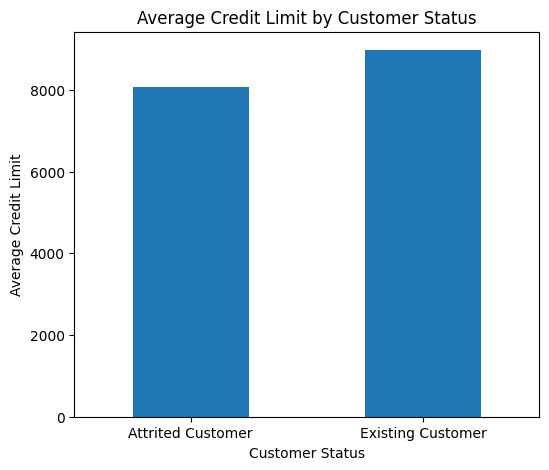

In [31]:
df.groupby('Attrition_Flag')['Credit_Limit'].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Average Credit Limit by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Credit Limit")

plt.xticks(rotation=0)

plt.show()

In [32]:
df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean()

,Total_Trans_Amt
Attrition_Flag,
Attrited Customer,1816.102459
Existing Customer,2899.413275


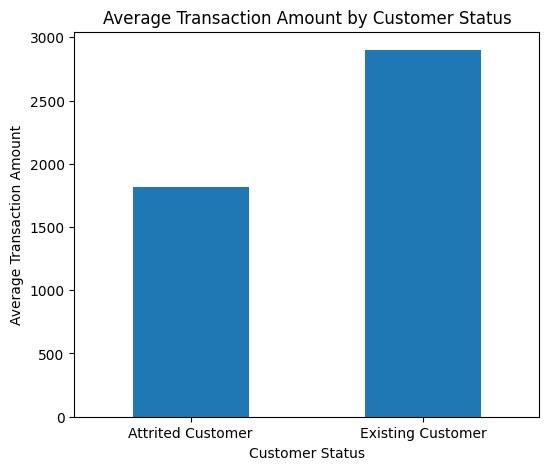

In [33]:
df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Average Transaction Amount by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=0)

plt.show()

In [34]:
df.groupby('Attrition_Flag')['Total_Trans_Ct'].mean()

,Total_Trans_Ct
Attrition_Flag,
Attrited Customer,36.547814
Existing Customer,56.680971


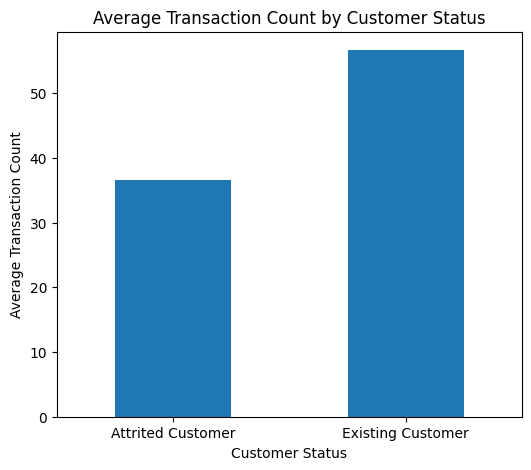

In [35]:
df.groupby('Attrition_Flag')['Total_Trans_Ct'].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Average Transaction Count by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Transaction Count")

plt.xticks(rotation=0)

plt.show()

In [36]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,1.000000,0.000732,-0.002221,0.126869,0.008927,0.011367,0.013410,0.008349,-0.008289,0.009062,0.011977,-0.003563,-0.004213,0.004816,-0.001838
Customer_Age,0.000732,1.000000,-0.132800,0.807086,-0.029170,0.024896,-0.023276,-0.002552,0.010212,-0.003462,-0.078356,-0.041890,-0.104187,-0.004163,-0.005588
Dependent_count,-0.002221,-0.132800,1.000000,-0.114287,-0.015284,-0.028688,-0.047796,0.112786,-0.000385,0.112363,-0.028818,0.077459,0.063082,0.031032,-0.061071
Months_on_book,0.126869,0.807086,-0.114287,1.000000,-0.021519,0.036479,-0.005967,0.007307,-0.000365,0.007310,-0.060408,-0.031937,-0.079540,-0.009579,-0.020736
Total_Relationship_Count,0.008927,-0.029170,-0.015284,-0.021519,1.000000,-0.046687,-0.051892,-0.002233,0.076488,-0.009113,0.052937,0.128831,0.139664,0.072133,0.058788
Months_Inactive_12_mon,0.011367,0.024896,-0.028688,0.036479,-0.046687,1.000000,0.033534,-0.004372,-0.032477,-0.001429,-0.041485,-0.030828,-0.027658,-0.036874,-0.008905
Contacts_Count_12_mon,0.013410,-0.023276,-0.047796,-0.005967,-0.051892,0.033534,1.000000,0.012929,-0.042618,0.016714,-0.047143,-0.016319,-0.007250,-0.085796,-0.034355
Credit_Limit,0.008349,-0.002552,0.112786,0.007307,-0.002233,-0.004372,0.012929,1.000000,0.000091,0.995936,-0.013076,-0.056627,-0.019101,0.016025,-0.510200
Total_Revolving_Bal,-0.008289,0.010212,-0.000385,-0.000365,0.076488,-0.032477,-0.042618,0.000091,1.000000,-0.089968,0.053664,-0.050131,-0.039314,0.094269,0.620989
Avg_Open_To_Buy,0.009062,-0.003462,0.112363,0.007310,-0.009113,-0.001429,0.016714,0.995936,-0.089968,1.000000,-0.017856,-0.051883,-0.015483,0.007470,-0.564056


In [37]:
import seaborn as sns

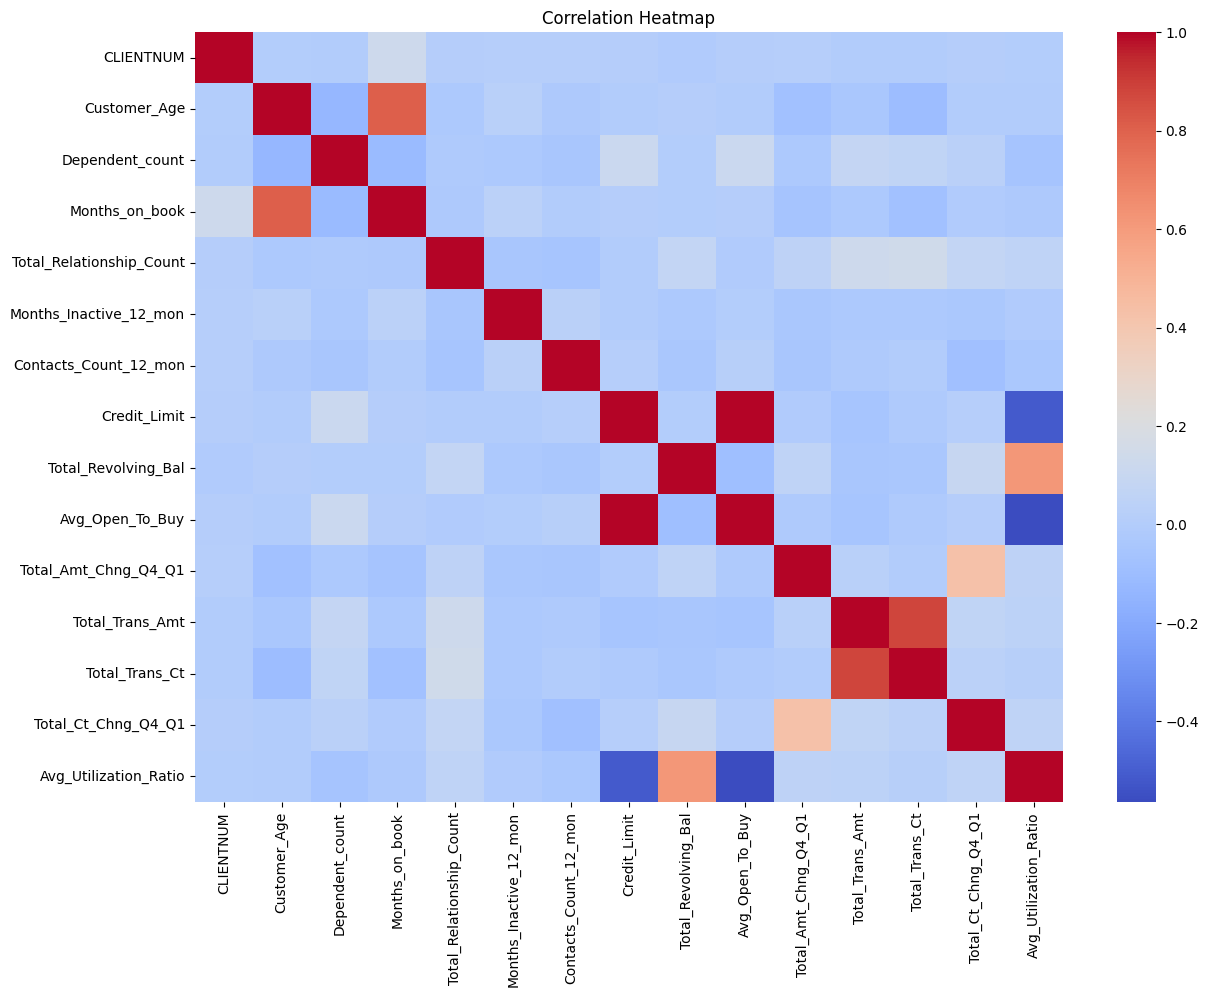

In [38]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=False,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
df.groupby('Attrition_Flag')['Customer_Age'].mean()

,Customer_Age
Attrition_Flag,
Attrited Customer,47.449454
Existing Customer,46.181873


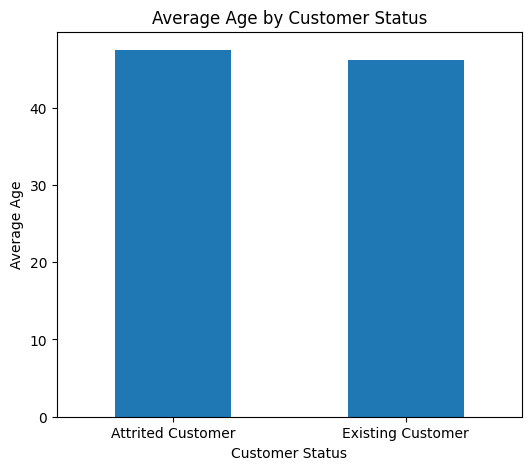

In [40]:
df.groupby('Attrition_Flag')['Customer_Age'].mean().plot(
    kind='bar',
    figsize=(6,5)
)

plt.title("Average Age by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Age")

plt.xticks(rotation=0)

plt.show()

In [41]:
df['Card_Category'].value_counts()

,count
Card_Category,
Blue,5431
Silver,253
Gold,32
Platinum,3


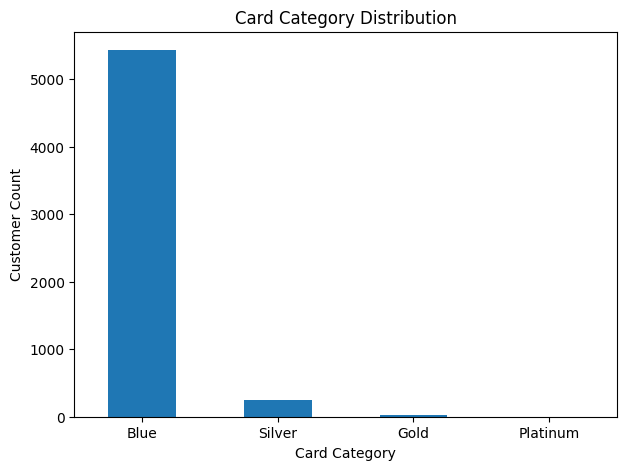

In [43]:
df['Card_Category'].value_counts().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Card Category Distribution")
plt.xlabel("Card Category")
plt.ylabel("Customer Count")

plt.xticks(rotation=0)

plt.show()

In [44]:
df.groupby('Card_Category')['Total_Trans_Amt'].mean()

,Total_Trans_Amt
Card_Category,
Blue,2760.317437
Gold,2850.625000
Platinum,1702.000000
Silver,2771.347826


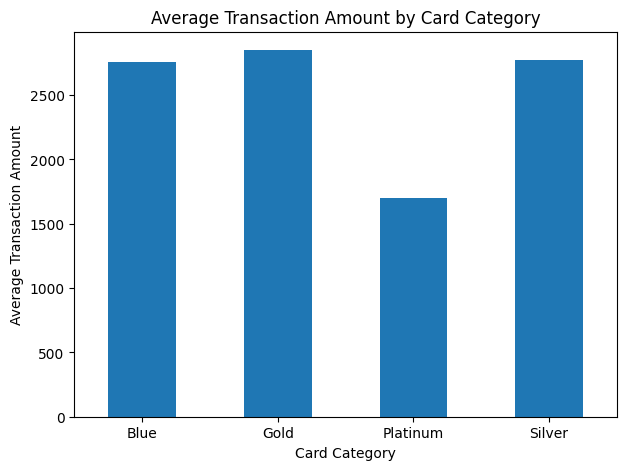

In [45]:
df.groupby('Card_Category')['Total_Trans_Amt'].mean().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Average Transaction Amount by Card Category")
plt.xlabel("Card Category")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=0)

plt.show()